In [ ]:
print("\nAny missing values?")
n_rows = df.shape[0]

print("=" * 80)
print(f"DataFrame : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print("=" * 80)

missing = df.isnull().sum().sort_values(ascending=True)

for col, val in missing.items():
    if val > 0:                                 # affiche seulement les colonnes avec manquants
        pct = val / n_rows * 100
        print(f"{col:.<45} {val:>8,} / {n_rows:,}     {pct:6.2f}%")


Any missing values?
DataFrame : 142,784 lignes × 24 colonnes
Nom_Commune..................................       27 / 142784       0.02%
Surface_Foret................................    4,650 / 142784       3.26%
Surface_Maquis_Garrigues.....................   24,733 / 142784      17.32%
Surfaces_Non_Boisees.........................   33,298 / 142784      23.32%
Autres_Surfaces_Naturelles...................   35,470 / 142784      24.84%
Type_Peuplement..............................   64,658 / 142784      45.28%
Nature.......................................   91,216 / 142784      63.88%
Surface_Autres_Terres_Boisees................  125,756 / 142784      88.07%
Precision_Surfaces...........................  126,892 / 142784      88.87%
Surfaces_Non_Boisees_Naturelles..............  132,089 / 142784      92.51%
Surfaces_Non_Boisees_Artificialisees.........  132,356 / 142784      92.70%
Deces_BatimentsTouches.......................  135,320 / 142784      94.77%
Surfaces_Agricoles........

In [23]:
DATABASE_NAME='incendies'

create_table_query = """
CREATE TABLE incendies_avec_commune AS
SELECT 
    i.*,
    c.nom_standard,
    c.dep_code,
    c.dep_nom,
    c.latitude_centre,
    c.longitude_centre,
    c.superficie_km2,
    c.population,
    c.densite,
    c.altitude_moyenne,
    c.grille_densite_texte
FROM tmp_incendie i
LEFT JOIN tmp_commune c ON i.Insee = c.code_insee;
"""

with engine.connect() as conn:
    conn.execute(text(f"USE {DATABASE_NAME}"))
    conn.execute(text(create_table_query))
    print("✅ Table 'incendies_avec_commune' créée")

✅ Table 'incendies_avec_commune' créée


In [24]:
TABLE_NAME='incendies_avec_commune'

df_list = []
for chunk in pd.read_sql_table(TABLE_NAME, engine, schema="incendies", chunksize=50000):
    df_list.append(chunk)
df = pd.concat(df_list, ignore_index=True)

print("\nAny missing values?")
n_rows = df.shape[0]

print("=" * 80)
print(f"DataFrame : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print("=" * 80)

missing = df.isnull().sum().sort_values(ascending=True)

for col, val in missing.items():
    if val > 0:                                 # affiche seulement les colonnes avec manquants
        pct = val / n_rows * 100
        print(f"{col:.<45} {val:>8,} / {n_rows:,}     {pct:6.2f}%")


Any missing values?
DataFrame : 142,784 lignes × 34 colonnes
Nom_Commune..................................       27 / 142,784       0.02%
densite......................................      915 / 142,784       0.64%
population...................................      915 / 142,784       0.64%
superficie_km2...............................      915 / 142,784       0.64%
dep_nom......................................      915 / 142,784       0.64%
dep_code.....................................      915 / 142,784       0.64%
nom_standard.................................      915 / 142,784       0.64%
altitude_moyenne.............................      915 / 142,784       0.64%
grille_densite_texte.........................      915 / 142,784       0.64%
longitude_centre.............................    1,761 / 142,784       1.23%
latitude_centre..............................    1,761 / 142,784       1.23%
Surface_Foret................................    4,650 / 142,784       3.26%
Surface_Maquis

In [2]:
from sqlalchemy import create_engine, text

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sqlalchemy import Engine
from sqlalchemy import text
from typing import Optional

# ================== PARAMÈTRES ==================
HOST = "localhost" 
PORT = 61306
USER = "hostuser" 
PASSWORD = "4SmW9sch"

DATABASE_NAME = "incendies"
TABLE_NAME='incendies_avec_commune'
# ===============================================

engine = create_engine(
    f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}"
)

# Test de connexion
def test_connection(engine) -> bool:
    try:
        with engine.connect() as conn:
            # Test simple et rapide
            result = conn.execute(text("SELECT VERSION()"))
            version = result.scalar()
            
            # Optionnel : lister les bases de données
            dbs = conn.execute(text("SHOW DATABASES")).fetchall()
            db_list = [db[0] for db in dbs]
            
            print("✅ Connexion réussie !")
            print(f"Version MySQL : {version}")
            print(f"Bases de données disponibles : {db_list}")
            
            return True
            
    except Exception as e:
        print("❌ Erreur de connexion :", e)
        return False

# chargement de la table
def load_table_to_dataframe(
    engine: Engine,
    table_name: str,
    schema: str = DATABASE_NAME,
    chunksize: int = 50000,
) -> pd.DataFrame:
    
    df_list = []
    
    for i, chunk in enumerate(pd.read_sql_table(
        table_name=table_name,
        con=engine,
        schema=schema,
        chunksize=chunksize
    )):
        df_list.append(chunk)

    if not df_list:
        return pd.DataFrame()
    df = pd.concat(df_list, ignore_index=True)
    
    return df

✅ Connexion réussie !
Version MySQL : 5.5.68-MariaDB
Bases de données disponibles : ['information_schema', 'arclight-igor', 'arclight-princeps', 'arclight-quad', 'incendies', 'mysql', 'performance_schema', 'test']


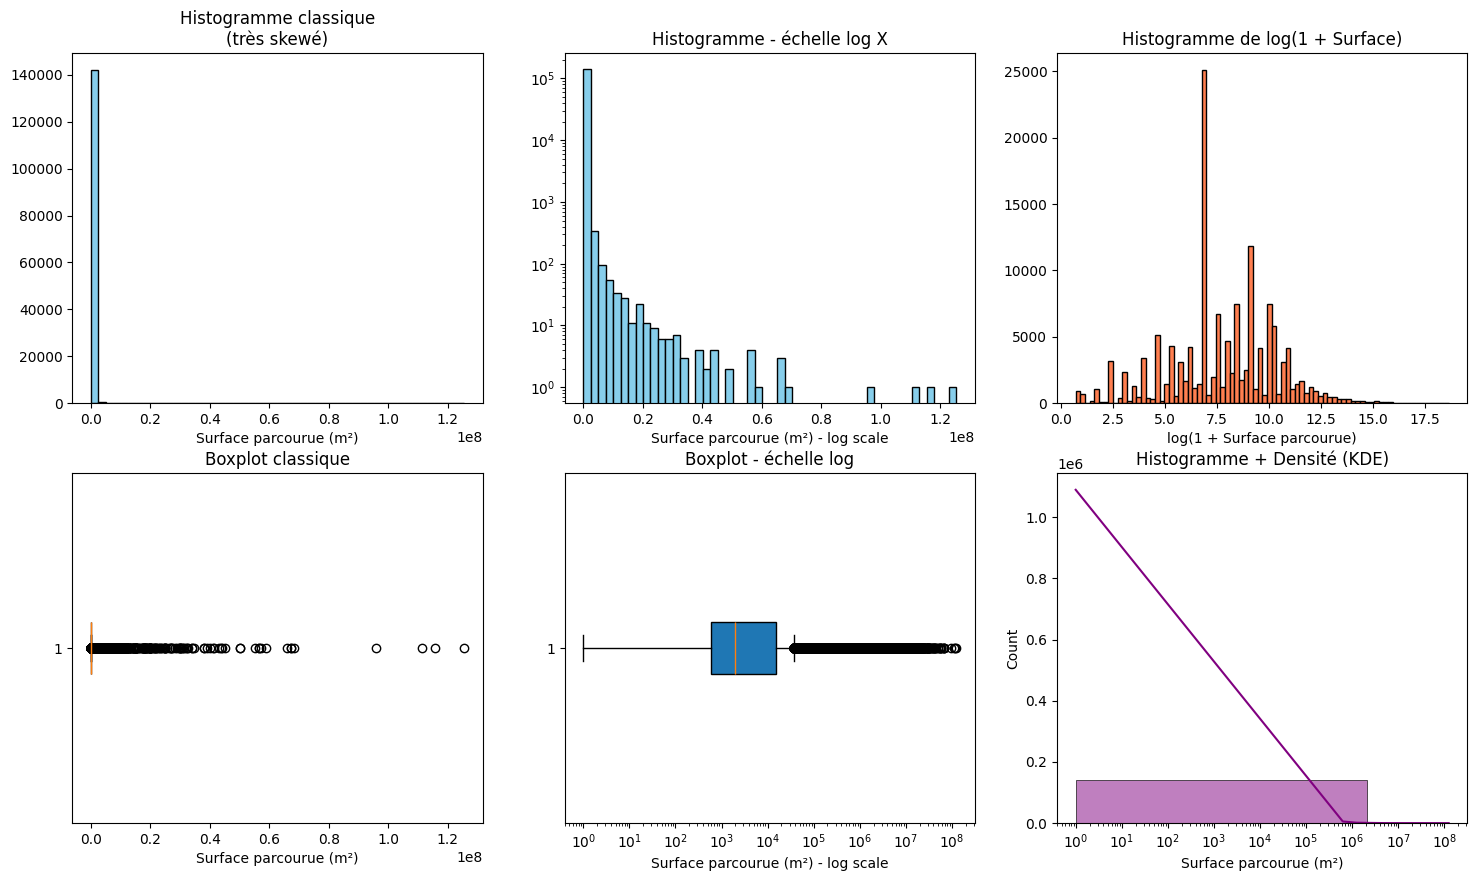

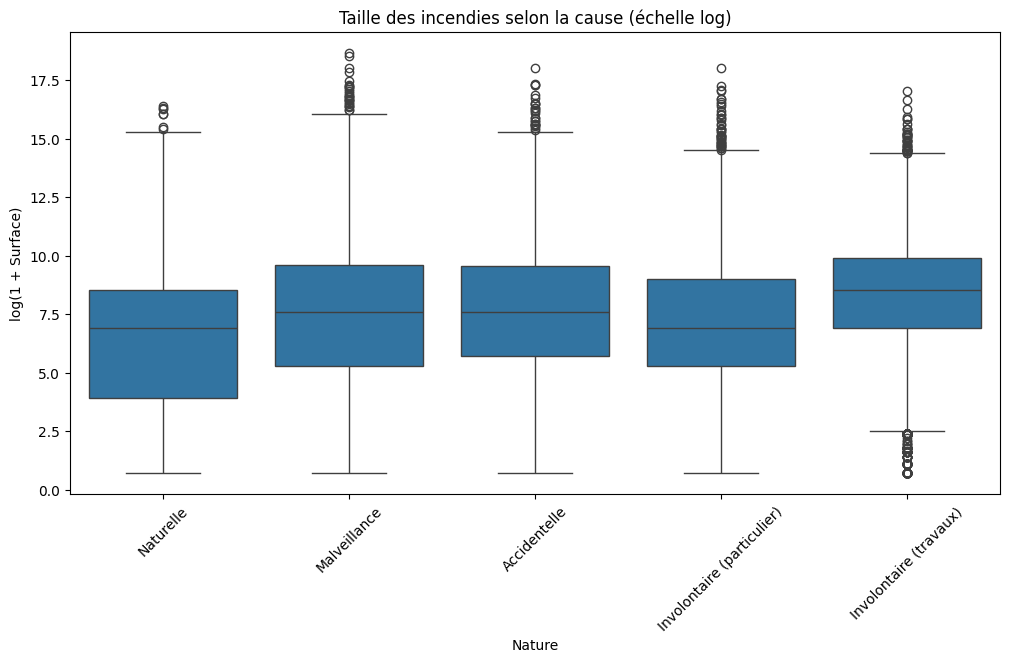

<Figure size 640x480 with 0 Axes>

In [ ]:
# Test Connection
if not test_connection(engine):
    print("Problème de connexion, vérifie tes identifiants.")
else:
    df = pd.DataFrame()
    df = load_table_to_dataframe(engine, TABLE_NAME)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Histogramme classique (pas très utile ici)
axes[0,0].hist(df['Surface_Parcourue'], bins=50, color='skyblue', edgecolor='black')
axes[0,0].set_title('Histogramme classique\n(très skewé)')
axes[0,0].set_xlabel('Surface parcourue (m²)')

# 2. Histogramme avec échelle log sur l'axe X
axes[0,1].hist(df['Surface_Parcourue'], bins=50, color='skyblue', edgecolor='black', log=True)
axes[0,1].set_title('Histogramme - échelle log X')
axes[0,1].set_xlabel('Surface parcourue (m²) - log scale')

# 3. Histogramme sur la variable log-transformée (le plus utile)
surface_log = np.log1p(df['Surface_Parcourue'])  # log(1 + x) pour gérer les 0
axes[0,2].hist(surface_log, bins=80, color='coral', edgecolor='black')
axes[0,2].set_title('Histogramme de log(1 + Surface)')
axes[0,2].set_xlabel('log(1 + Surface parcourue)')

# 4. Boxplot (montre les outliers)
axes[1,0].boxplot(df['Surface_Parcourue'], vert=False, patch_artist=True)
axes[1,0].set_title('Boxplot classique')
axes[1,0].set_xlabel('Surface parcourue (m²)')

# 5. Boxplot en échelle log
axes[1,1].boxplot(df['Surface_Parcourue'], vert=False, patch_artist=True)
axes[1,1].set_xscale('log')
axes[1,1].set_title('Boxplot - échelle log')
axes[1,1].set_xlabel('Surface parcourue (m²) - log scale')

# 6. Histogramme + KDE (très joli avec seaborn)
sns.histplot(df['Surface_Parcourue'], kde=True, bins=60, ax=axes[1,2], color='purple')
axes[1,2].set_title('Histogramme + Densité (KDE)')
axes[1,2].set_xlabel('Surface parcourue (m²)')
axes[1,2].set_xscale('log')

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Nature', y=np.log1p(df['Surface_Parcourue']))
plt.title('Taille des incendies selon la cause (échelle log)')
plt.ylabel('log(1 + Surface)')
plt.xticks(rotation=45)
plt.show()

plt.tight_layout()
plt.show()

In [5]:
col = 'Surface_Parcourue'

quantiles = [0.5, 0.75, 0.9, 0.95, 0.99, 0.995, 0.999]
stats = df[col].quantile(quantiles).reset_index()
stats.columns = ['Quantile', 'Surface_m2']
stats['Surface_ha'] = stats['Surface_m2'] / 10000
stats['Surface_ha'] = stats['Surface_ha'].round(2)

print(stats.round(2))

   Quantile  Surface_m2  Surface_ha
0      0.50      2000.0        0.20
1      0.75     15000.0        1.50
2      0.90     50000.0        5.00
3      0.95    120000.0       12.00
4      0.99   1000000.0      100.00
5      1.00   2310059.5      231.01
6      1.00  11228680.0     1122.87


In [9]:
df['Surface_Parcourue'].sum() / 10000

np.float64(1079918.1489)

/tmp/ipykernel_5825/3880024509.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Nature', loc='upper right')


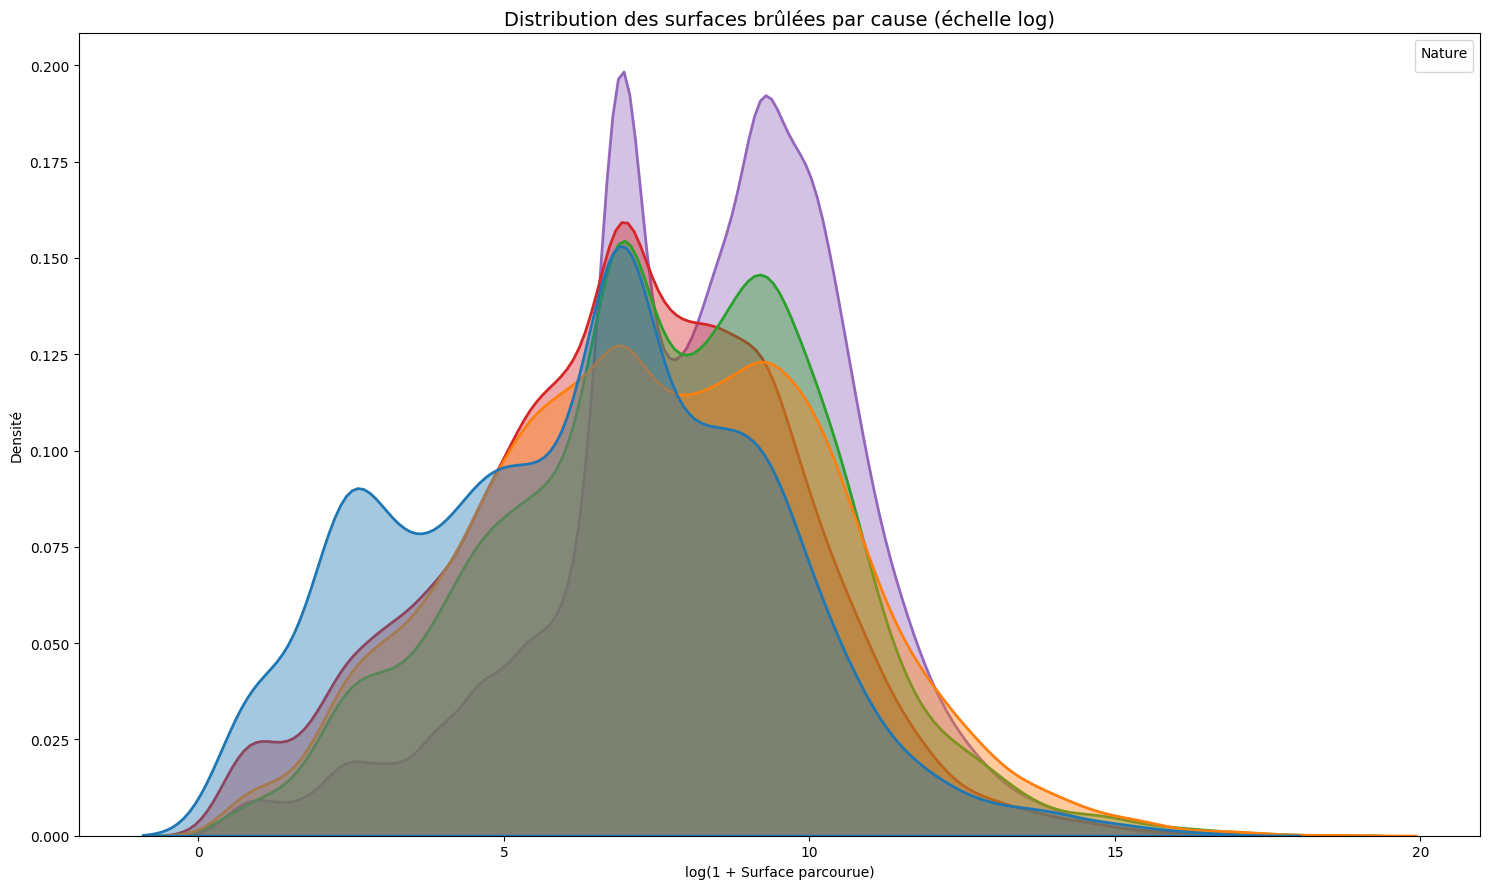

In [13]:
plt.figure(figsize=(15, 9))

# Création du plot
ax = sns.kdeplot(
    data=df,
    x=np.log1p(df['Surface_Parcourue']),
    hue='Nature',
    fill=True,
    common_norm=False,
    alpha=0.4,
    linewidth=2,
    palette='tab10'
)

plt.title('Distribution des surfaces brûlées par cause (échelle log)', fontsize=14)
plt.xlabel('log(1 + Surface parcourue)')
plt.ylabel('Densité')

# === SOLUTION POUR FORCER LA LÉGENDE ===
handles, labels = ax.get_legend_handles_labels()
if handles:  # si seaborn a bien créé les handles
    plt.legend(handles, labels, title='Nature', fontsize=11, title_fontsize=12, loc='upper right')
else:
    # Solution de secours si ça ne marche toujours pas
    plt.legend(title='Nature', loc='upper right')

plt.tight_layout()
plt.show()

In [11]:
# Test Connection
if not test_connection(engine):
    print("Problème de connexion, vérifie tes identifiants.")
else:
    df = pd.DataFrame()
    df = load_table_to_dataframe(engine, TABLE_NAME)



✅ Connexion réussie !
Version MySQL : 5.5.68-MariaDB
Bases de données disponibles : ['information_schema', 'arclight-igor', 'arclight-princeps', 'arclight-quad', 'incendies', 'mysql', 'performance_schema', 'test']


In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mapping détaillé
mapping_vegetation = {
    1.0: 'Maquis / Garrigues / Landes',
    2.0: 'Taillis',
    3.0: 'Futaies Feuillues',
    4.0: 'Futaies Résineuses',
    5.0: 'Futaies Mélangées',
    6.0: 'Régénération / Reboisement',
    np.nan: 'Non renseigné'
}
df['vegetation_type'] = df['Type_Peuplement'].map(mapping_vegetation)

print(round(df['vegetation_type'].value_counts(dropna=False, normalize=True)*100, 2))


df['Type_Peuplement'] = df['Type_Peuplement'].fillna(0)  # 0 = Non renseigné

df['vegetation_maquis'] = (df['Type_Peuplement'] == 1).astype(int)
df['vegetation_resineux'] = (df['Type_Peuplement'] == 4).astype(int)
df['vegetation_feuillu'] = (df['Type_Peuplement'] == 3).astype(int)
df['vegetation_reboisement'] = (df['Type_Peuplement'] == 6).astype(int)

# Mapping amélioré selon les surfaces réelles observées
df['vegetation_risk_score'] = df['Type_Peuplement'].map({
    0: 7.5,   # Non renseigné → risque assez élevé (on l'a vu sur les graphiques)
    1: 7.0,   # Maquis/Garrigues → fréquent mais pas le plus dangereux
    2: 6.0,   # Taillis
    3: 4.5,   # Futaies Feuillues → moins risqué
    4: 9.0,   # Futaies Résineuses → le plus risqué
    5: 7.5,   # Futaies Mélangées
    6: 8.0    # Régénération / Reboisement → risque élevé
})

# Optionnel : arrondir pour plus de simplicité
df['vegetation_risk_score'] = df['vegetation_risk_score'].round(1)

# Distribution du score
print("=== DISTRIBUTION DU VEGETATION_RISK_SCORE ===")
print(df['vegetation_risk_score'].value_counts().sort_index())

# Statistiques
print("\nStatistiques descriptives :")
print(df['vegetation_risk_score'].describe())




vegetation_type
NaN                            45.28
Maquis / Garrigues / Landes    39.67
Futaies Résineuses              5.11
Futaies Mélangées               4.12
Futaies Feuillues               3.69
Régénération / Reboisement      1.14
Taillis                         0.99
Name: proportion, dtype: float64
=== DISTRIBUTION DU VEGETATION_RISK_SCORE ===
vegetation_risk_score
4.5     5266
6.0     1413
7.0    56638
7.5    70542
8.0     1624
9.0     7301
Name: count, dtype: int64

Statistiques descriptives :
count    142784.000000
mean          7.258565
std           0.716217
min           4.500000
25%           7.000000
50%           7.500000
75%           7.500000
max           9.000000
Name: vegetation_risk_score, dtype: float64


In [24]:
pd.set_option('display.max_colwidth', None)      # pas de limite sur la largeur d'une colonne
pd.set_option('display.width', 1600)             # largeur totale de la ligne
pd.set_option('display.max_columns', None)       # affiche toutes les colonnes
pd.set_option('display.max_rows', 200)

# 1. Tableau statistique (le plus important)
impact = df.groupby('vegetation_risk_score').agg({
    'Surface_Parcourue': ['count', 'mean', 'median', 'max', 'sum'],
    'Type_Peuplement': 'count'
}).round(2)

impact.columns = ['Nb_incendies', 'Surface_moy_m2', 'Surface_med_m2', 'Surface_max_m2', 'Surface_tot_m2','Type_Peuplement_count']
impact['Surface_moy_ha'] = impact['Surface_moy_m2'] / 10000
impact['Surface_med_ha'] = impact['Surface_med_m2'] / 10000

print(impact)

                       Nb_incendies  Surface_moy_m2  Surface_med_m2  Surface_max_m2  Surface_tot_m2  Type_Peuplement_count  Surface_moy_ha  Surface_med_ha
vegetation_risk_score                                                                                                                                     
4                              5266        98656.06          4458.0        56460000       519522809                   5266        9.865606         0.44580
5                             64658        67829.94          1500.0       125520000      4385748541                  64658        6.782994         0.15000
6                              1413        47115.43          2000.0        17040000        66574103                   1413        4.711543         0.20000
7                              5884       115520.86          2333.5        68320000       679724756                   5884       11.552086         0.23335
8                             58262        73652.40          3000.0   

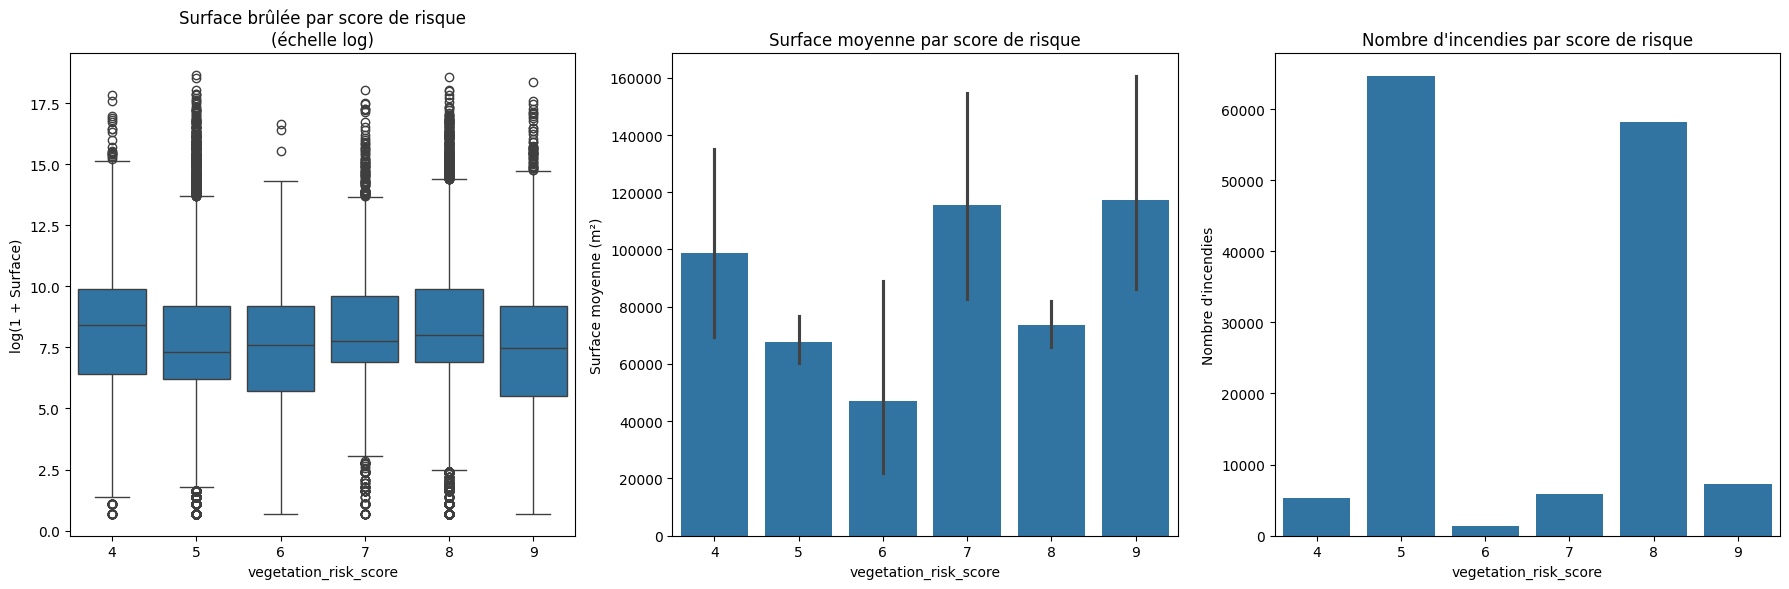

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Boxplot : Surface selon le score (échelle log)
sns.boxplot(data=df, x='vegetation_risk_score', y=np.log1p(df['Surface_Parcourue']), ax=axes[0])
axes[0].set_title('Surface brûlée par score de risque\n(échelle log)')
axes[0].set_ylabel('log(1 + Surface)')

# Barplot : Surface moyenne par score
sns.barplot(data=df, x='vegetation_risk_score', y='Surface_Parcourue', estimator='mean', ax=axes[1])
axes[1].set_title('Surface moyenne par score de risque')
axes[1].set_ylabel('Surface moyenne (m²)')

# Nombre d'incendies par score
sns.countplot(data=df, x='vegetation_risk_score', ax=axes[2])
axes[2].set_title("Nombre d'incendies par score de risque")
axes[2].set_ylabel('Nombre d\'incendies')

plt.tight_layout()
plt.show()

In [ ]:
S